In [31]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt 

In [32]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df.sample(5)

,Class label,Alcohol,Malic acid
82,2,12.08,1.13
20,1,14.06,1.63
174,3,13.40,3.91
132,3,12.81,2.31
95,2,12.47,1.52


<Axes: xlabel='Alcohol', ylabel='Malic acid'>

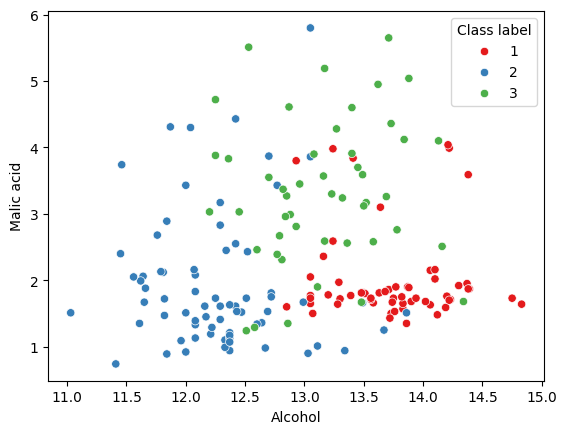

In [33]:
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette='Set1')

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df.drop('Class label', axis=1), 
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

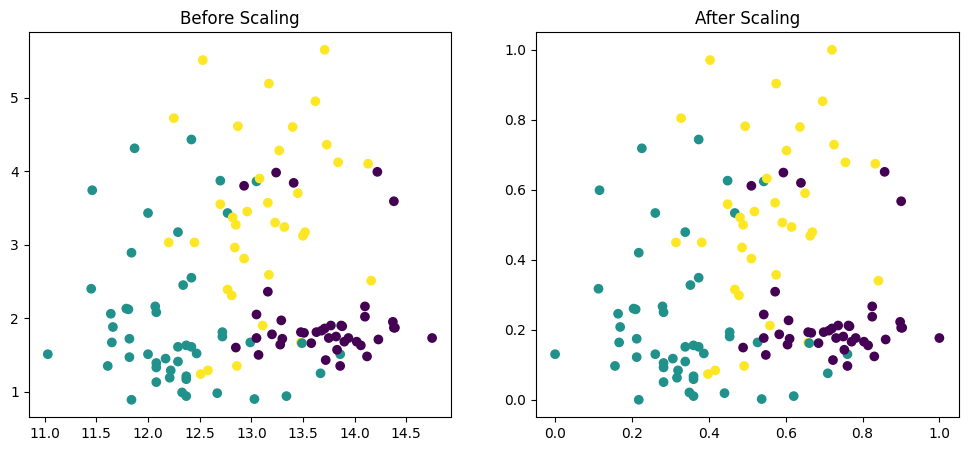

In [37]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=Y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=Y_train)
ax2.set_title("After Scaling")
plt.show()